# Note

This script is runnable on **Windows**, and works (with slight modification) on **Ubuntu** and **MacOS**.

First read the `mcap` file as follows:

In [1]:
from mcap_ros2.decoder import DecoderFactory
from mcap.reader import make_reader
import sys

source_file1 = 'C:\\Users\\he\\Downloads\\nissan_zala_50_zeg_4_0.mcap'
source_file1 = '/mnt/c/Users/he/Downloads/nissan_zala_50_zeg_4_0.mcap'

"""Reads all channels from an MCAP file."""
x_pos1 = []
y_pos1 = []
with open(source_file1, "rb") as f:
    reader = make_reader(f, decoder_factories=[DecoderFactory()])
    channels = reader.get_summary().channels.items()
    print("Read %d channels from %s" % (len(channels), source_file1))
    reader = make_reader(f, decoder_factories=[DecoderFactory()])
    #iterate over all messages
    for schema, channel, message, msg in reader.iter_decoded_messages():
        if (channel.topic == "/nissan/gps/duro/current_pose" or channel.topic == "/nissan9/gps/duro/current_pose"):
            x_pos1.append(msg.pose.position.x)
            y_pos1.append(msg.pose.position.y)
print("Position size %d, last values (%.1f, %.1f)" % (len(x_pos1), x_pos1[-1], y_pos1[-1]))

Read 6 channels from /mnt/c/Users/he/Downloads/nissan_zala_50_zeg_4_0.mcap
Position size 1992, last values (221.3, -332.9)


After that we can easily plot it with `matplotlib:

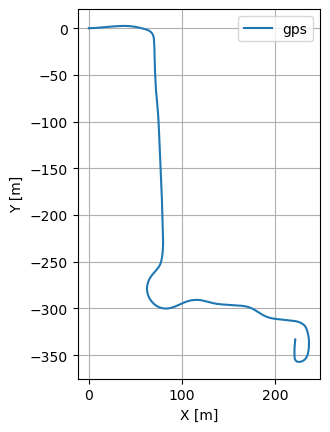

In [2]:
import matplotlib.pyplot as plt

plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.grid(True)
plt.plot(x_pos1, y_pos1, label='gps')
plt.legend()
plt.show()